# **CLAHE Application on Brain MRI Dataset**

Import the required packages.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import imutils
import cv2
from PIL import Image
import random
from gtda.homology import CubicalPersistence
from gtda.diagrams import PersistenceLandscape

We will look at the first 44 Glioma images. Adjust the `file_path` variable to work on your computer.

In [11]:
# Initialize a list to contain the first 44 images.
filenames = []

# Initialize a string containing the file path.
file_path = "MRI/Training/glioma/"

# Iterate through the folder and add the first 44 files to the list.
for i in range(10, 55):
  filenames.append(file_path + "Tr-gl_00" + str(i) + ".jpg")

We will choose a random image and pre-process it.

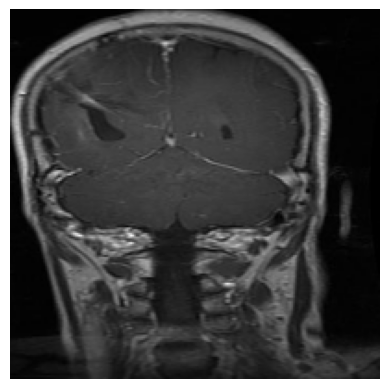

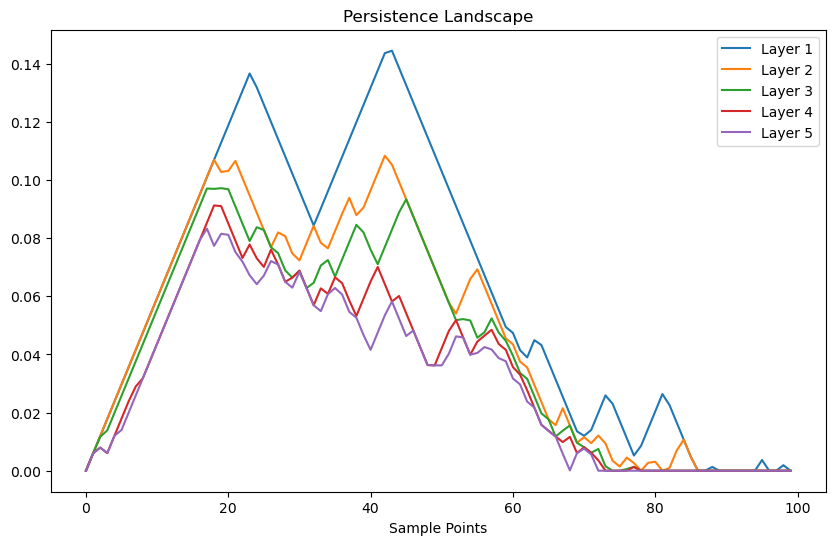

In [38]:
def crop_img(img):
	"""
	Finds the extreme points on the image and crops the rectangular out of them
	"""
	gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
	gray = cv2.GaussianBlur(gray, (3, 3), 0)

	# threshold the image, then perform a series of erosions +
	# dilations to remove any small regions of noise
	thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
	thresh = cv2.erode(thresh, None, iterations=2)
	thresh = cv2.dilate(thresh, None, iterations=2)

	# find contours in thresholded image, then grab the largest one
	cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
	cnts = imutils.grab_contours(cnts)
	c = max(cnts, key=cv2.contourArea)

	# find the extreme points
	extLeft = tuple(c[c[:, :, 0].argmin()][0])
	extRight = tuple(c[c[:, :, 0].argmax()][0])
	extTop = tuple(c[c[:, :, 1].argmin()][0])
	extBot = tuple(c[c[:, :, 1].argmax()][0])
	ADD_PIXELS = 0
	new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

	return new_img

# Pick a random file from the list of filenames.
image_path = random.choice(filenames)

# Load and preprocess the image
IMG_SIZE = 200
image = cv2.imread(image_path)

cropped = crop_img(image)
resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
resized_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB) #This step is necessary for displaying the image correctly in matplotlib (We will remove it when training for the whole folder)

# Show image in notebook
plt.imshow(resized_rgb)
plt.axis("off")
plt.show()

# Convert to grayscale for cubical persistence
gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
gray = gray / 255.0  # Normalize to [0,1]

# Prepare shape (n_samples, height, width)
X = gray[np.newaxis, :, :]

# Compute cubical persistence
cp = CubicalPersistence(homology_dimensions=(0, 1))
cp.fit(X)
diagrams = cp.fit_transform(X)

# Plot the persistence diagram
fig = cp.plot(diagrams, sample=0)
fig.update_layout(title="Persistence Diagram")
fig.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5) 
landscapes = pl.fit_transform(diagrams)

# Plot the persiste
plt.figure(figsize=(10, 6))
for i in range(min(5, landscapes.shape[1])): 
    plt.plot(landscapes[0, i], label=f'Layer {i+1}')
plt.xlabel("Sample Points")
plt.title("Persistence Landscape")
plt.legend()
plt.show()


We will apply CLAHE on the image.

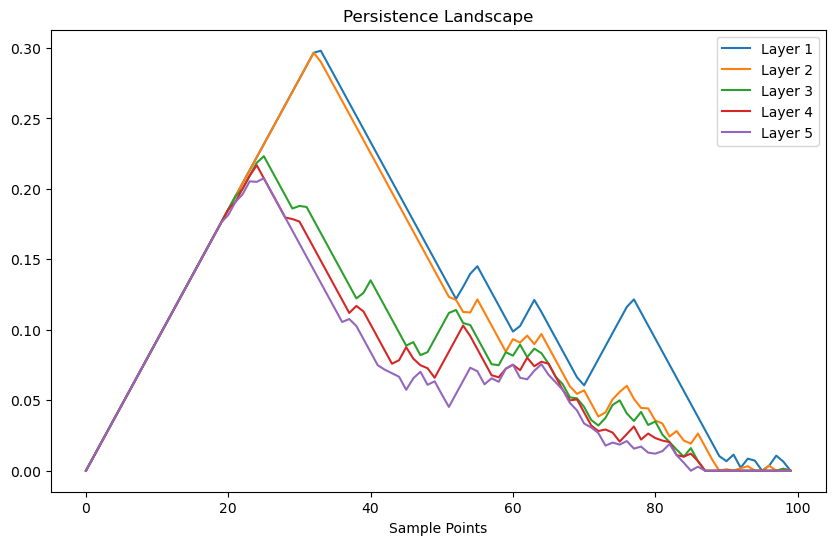

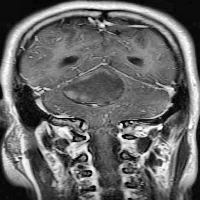

In [36]:
# Load your image array
img = np.array(resized_rgb)

# Convert the image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))

# Apply CLAHE
clahe_img = clahe.apply(img)

# Normalize for GTDA
normalized_clahe = clahe_img / 255.0
X_clahe = normalized_clahe[np.newaxis, :, :]

# Compute Cubical Persistence
cp_clahe = CubicalPersistence(homology_dimensions=(0, 1))
cp_clahe.fit(X_clahe)
diagrams_clahe = cp_clahe.fit_transform(X_clahe)

# Plotting
fig_clahe = cp_clahe.plot(diagrams_clahe, sample=0)
fig_clahe.update_layout(title="Persistence Diagram (CLAHE Image)")
fig_clahe.show()

# Compute persistence landscape
pl = PersistenceLandscape(n_layers=5) 
landscapes = pl.fit_transform(diagrams_clahe)

# Plot the persistence landscape
plt.figure(figsize=(10, 6))
for i in range(min(5, landscapes.shape[1])): 
    plt.plot(landscapes[0, i], label=f'Layer {i+1}')
plt.xlabel("Sample Points")
plt.title("Persistence Landscape")
plt.legend()
plt.show()

# Convert clahe_img to a PIL image
clahe_img = Image.fromarray(clahe_img)

# Display the CLAHE image
clahe_img

We can examine the distribution of the resulting CLAHE image.

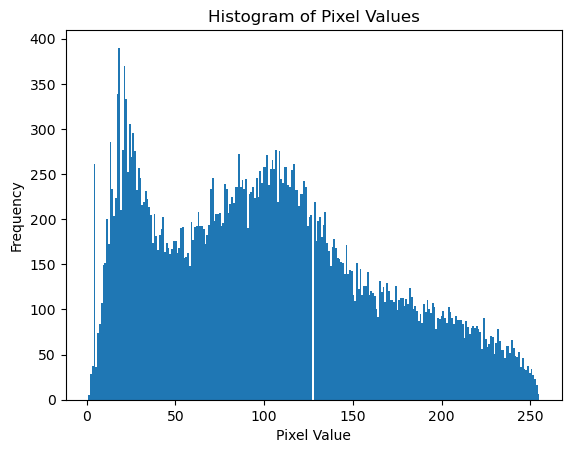

In [9]:
# Extract the 2D array of pixel values from the CLAHE image.
img_array = np.array(clahe_img)

# Initialize a list to all the pixel values.
pixels = []

# Add each pixel's value to the initialized list.
for i in range(len(img_array)):
  for j in range(len(img_array[i])):
    pixels.append(img_array[i][j])

# Plot the histogram of the values in the list.
plt.hist(pixels, bins=256)
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram of Pixel Values')
plt.show()